In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


In [12]:
df = pd.read_csv('bank-additional-full.csv', sep=';')

print("Dataset Shape:", df.shape)
print("Display First 5 rows:")
df.head()



Dataset Shape: (41188, 21)
Display First 5 rows:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [13]:
# convert target from yes no to binary
df['y'] = df['y'].map({'yes': 1, 'no': 0})

In [14]:
print("Missing Values:", df.isnull().sum())

Missing Values: age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


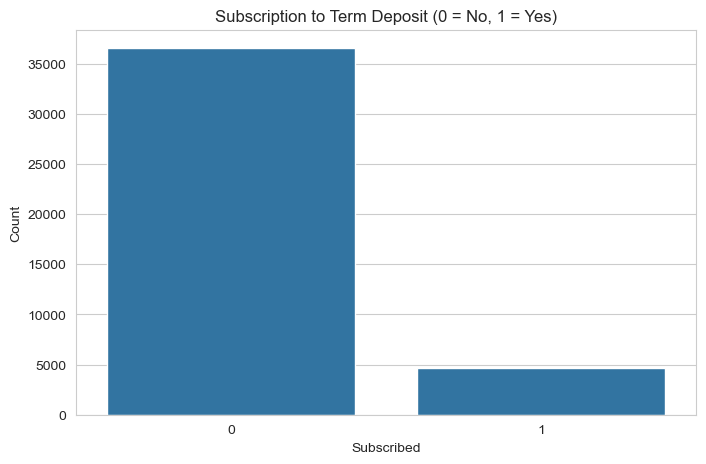

In [16]:
plt.figure(figsize=(8,5))
sns.countplot(x='y', data=df)
plt.title('Subscription to Term Deposit (0 = No, 1 = Yes)')
plt.xlabel('Subscribed')
plt.ylabel('Count')
plt.show()

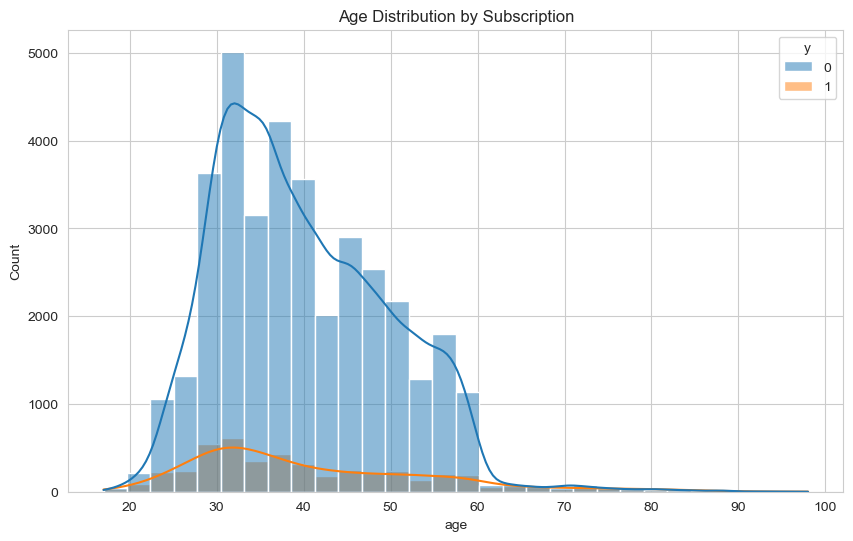

In [17]:
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='age', hue='y', kde=True, bins=30)
plt.title('Age Distribution by Subscription')
plt.show()

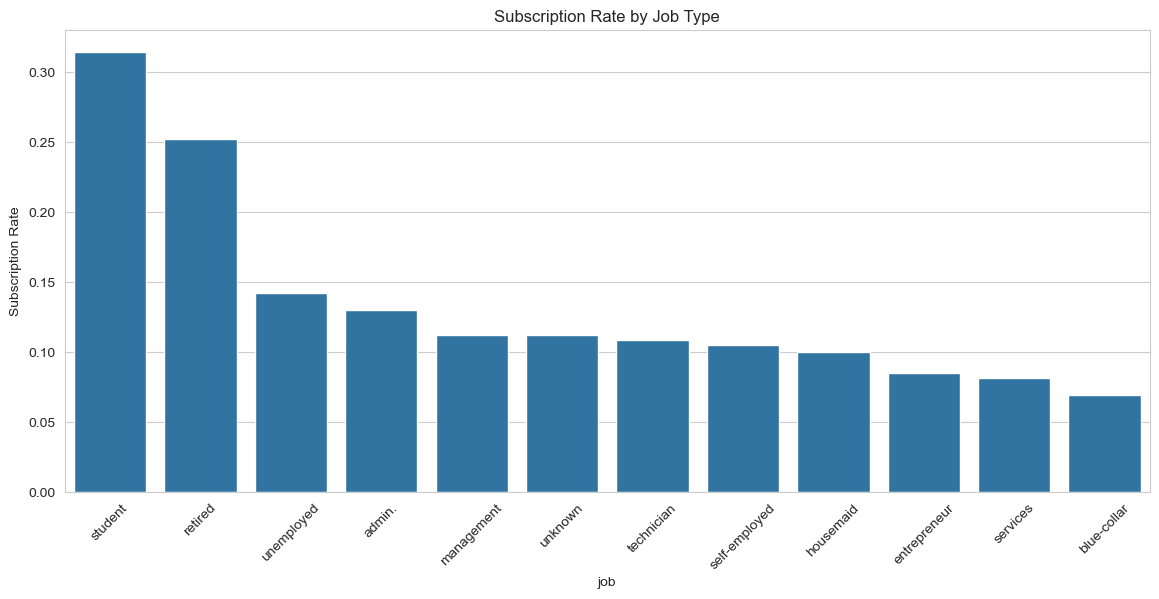

In [18]:
plt.figure(figsize=(14,6))
job_sub = df.groupby('job')['y'].mean().sort_values(ascending=False)
sns.barplot(x=job_sub.index, y=job_sub.values)
plt.xticks(rotation=45)
plt.title('Subscription Rate by Job Type')
plt.ylabel('Subscription Rate')
plt.show()

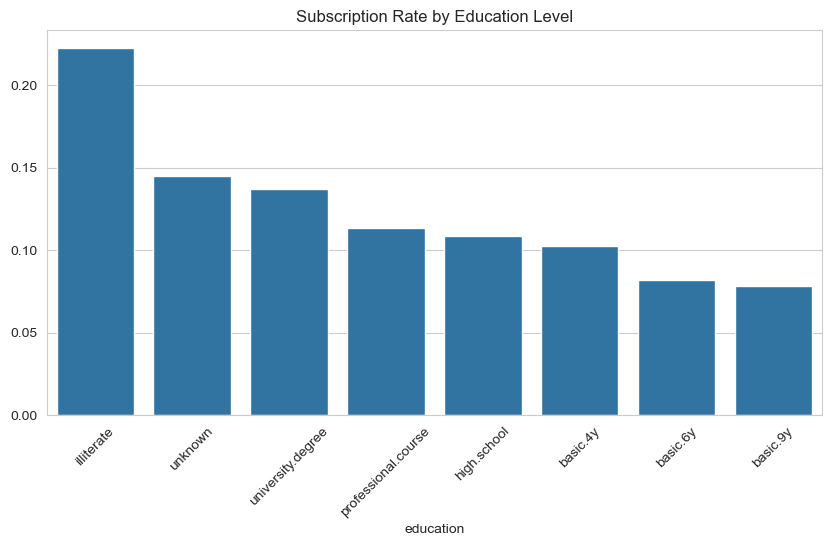

In [19]:
plt.figure(figsize=(10,5))
edu_sub = df.groupby('education')['y'].mean().sort_values(ascending=False)
sns.barplot(x=edu_sub.index, y=edu_sub.values)
plt.xticks(rotation=45)
plt.title('Subscription Rate by Education Level')
plt.show()

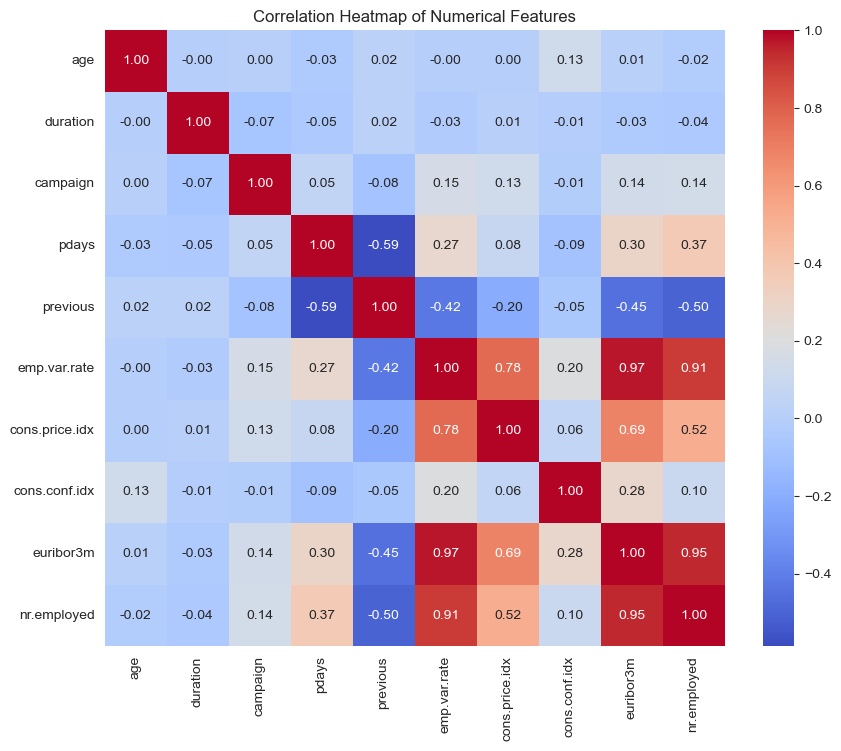

In [20]:
numerical_cols = ['age', 'duration', 'campaign', 'pdays', 'previous', 
                  'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 
                  'euribor3m', 'nr.employed']

plt.figure(figsize=(10,8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()